In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv('attendance.csv')

In [5]:
X = df['DBMS'].values
y = df['Total'].values

In [6]:
print(f"We'll use DBMS attendance to predict Total attendance")
print(f"\nFirst 5 students:")
for i in range(5):
    print(f"  DBMS={X[i]}, Total={y[i]}")

input("\nPress Enter to continue...")

We'll use DBMS attendance to predict Total attendance

First 5 students:
  DBMS=10, Total=50
  DBMS=6, Total=36
  DBMS=7, Total=41
  DBMS=3, Total=14
  DBMS=12, Total=90


''

In [8]:
X_2d = X.reshape(-1,1)
results = {}

In [ ]:
# Degree 1: straight line
degree = 1
model1 = LinearRegression()
model1.fit(X_2d, y)
y_pred1 = model1.predict(X_2d)
r2_1 = r2_score(y, y_pred1)

results[1] = {'model': model1, 'r2': r2_1, 'predictions': y_pred1}
print(f"   Accuracy (R²): {r2_1:.3f} = {r2_1*100:.1f}%")

   Accuracy (R²): 0.874 = 87.4%


In [13]:
# Degree 2: curved line
degree = 2
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X_2d)
model2 = LinearRegression()
model2.fit(X_poly2,y)
y_pred2 = model2.predict(X_poly2)
r2_2 = r2_score(y,y_pred2)

results[2] = {'model': model2, 'poly': poly2, 'r2': r2_2, 'predictions': y_pred2}
print(f"   Accuracy (R²): {r2_2:.3f} = {r2_2*100:.1f}%")

   Accuracy (R²): 0.885 = 88.5%


In [16]:
# Degree 3: more curved line
degree = 3
# Transform: [X] → [X, X², X³]
poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X_2d)

model3 = LinearRegression()
model3.fit(X_poly3, y)
y_pred3 = model3.predict(X_poly3)
r2_3 = r2_score(y, y_pred3)

results[3] = {'model': model3, 'poly': poly3, 'r2': r2_3, 'predictions': y_pred3}
print(f"   Accuracy (R²): {r2_3:.3f} = {r2_3*100:.1f}%")


   Accuracy (R²): 0.885 = 88.5%


In [19]:
best_degree = max([1, 2, 3], key=lambda d: results[d]['r2'])
best_r2 = results[best_degree]['r2']

print(f"\n🏆 WINNER: Degree {best_degree}")
print(f"   Accuracy: {best_r2*100:.1f}%")


🏆 WINNER: Degree 3
   Accuracy: 88.5%


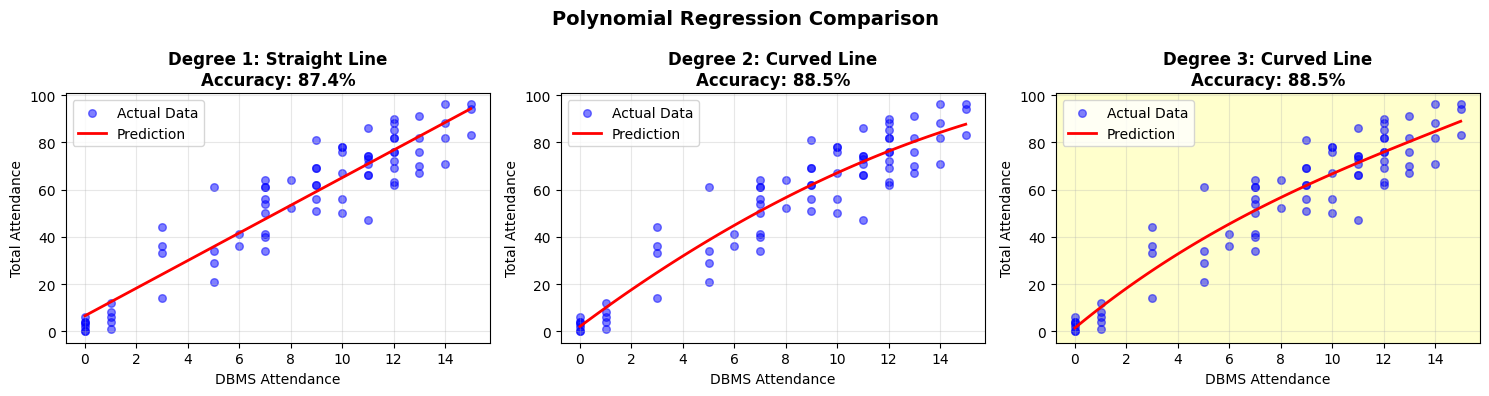

In [20]:
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Polynomial Regression Comparison', fontsize=14, fontweight='bold')

for i, degree in enumerate([1, 2, 3]):
    ax = axes[i]
    
    # Plot actual data points
    ax.scatter(X, y, color='blue', alpha=0.5, s=30, label='Actual Data')
    
    # Plot prediction line
    if degree == 1:
        y_line = results[1]['model'].predict(X_line)
        title = f"Degree 1: Straight Line"
    else:
        poly = results[degree]['poly']
        X_line_poly = poly.transform(X_line)
        y_line = results[degree]['model'].predict(X_line_poly)
        title = f"Degree {degree}: Curved Line"
    
    ax.plot(X_line, y_line, color='red', linewidth=2, label='Prediction')
    
    # Labels
    r2 = results[degree]['r2']
    ax.set_title(f"{title}\nAccuracy: {r2*100:.1f}%", fontweight='bold')
    ax.set_xlabel('DBMS Attendance')
    ax.set_ylabel('Total Attendance')
    ax.legend()
    ax.grid(True, alpha=0.3)

    if degree == best_degree:
        ax.set_facecolor('#ffffcc')
    
    
plt.tight_layout()
plt.show()

In [21]:
print(f"\nUsing Degree {best_degree} model to predict:")
print("-" * 40)

test_values = [5, 10, 15]

for dbms in test_values:
    X_new = np.array([[dbms]])
    
    if best_degree == 1:
        prediction = results[1]['model'].predict(X_new)[0]
    else:
        poly = results[best_degree]['poly']
        X_new_poly = poly.transform(X_new)
        prediction = results[best_degree]['model'].predict(X_new_poly)[0]
    
    print(f"If DBMS = {dbms:2d} days → Total = {prediction:.0f} days")


Using Degree 3 model to predict:
----------------------------------------
If DBMS =  5 days → Total = 39 days
If DBMS = 10 days → Total = 67 days
If DBMS = 15 days → Total = 89 days
